In [2]:
"""
Import required libraries
"""

%load_ext autoreload
%autoreload 2

import sys
import os

sys.path.append(os.path.abspath(os.path.join("..")))

import numpy as np
import pandas as pd
import seaborn as sns
import pickle

from src.util import *
from src.benchmark_ssm.hi_smc import *
from src.benchmark_ssm.pf import *
from src.benchmark_ssm.ssm import *
from src.benchmark_ssm.mh import *
from src.linear_ssm.hi_smc import *
from src.linear_ssm.pf import *
from src.linear_ssm.ssm import *
from src.linear_ssm.mh import *
from src.nonlinear_ssm.hi_smc import *
from src.nonlinear_ssm.pf import *
from src.nonlinear_ssm.ssm import *
from src.nonlinear_ssm.mh import *

from itertools import product

import time

In [42]:
""" Experiment 1: adaptive metropolis-hastings + different parameter choices
"""

temp = 1.0 # Initial tempering
T = 200 # Number of observations
                              
theta = 1 # True parameter                              

# Keep track of lots of stuff
record_of_records = {}

rng = np.random.default_rng(seed=42) # Want to fix this while keeping the rest random
us = rng.normal(loc=0, scale=1, size=T) 

# Sample observations from true state-space model
_, ys = SimpleBenchmarkSSM_simulate(T=T,theta=theta,us=us,rng=rng)

record_of_records = {}

for alternative_tempering, n_filter_particles, n_sample_particles, repeat in product(
    [True, False],
    [25, 50, 100],
    [25, 50, 100],
    list(range(10))
):
    if alternative_tempering:
        temp = 1.0
    else:
        temp = 10.0
        
    params = {
        "repeat": repeat,
        "alternative_tempering": alternative_tempering,
        "n_filter_particles": n_filter_particles,
        "n_sample_particles": n_sample_particles,
    }

    key = tuple(params.items())

    t0 = time.time()
    print(f"Starting run with params {params}")

    samples, records = SimpleBenchmarkSSM_smc(
        ys=ys,
        us=us,
        initial_mh_iters=100,
        initial_mh_sd=0.5,
        mh_iters=25,
        mh_sd=0.02,
        n_sample_particles=n_sample_particles,
        n_filter_particles=n_filter_particles,
        temp=temp,
        min_temp=0.01,
        alpha=0.5,
        verbose=False,
        alternative_tempering=alternative_tempering,
        adaptive_pmh=True,
    )

    t1 = time.time()
    print(f"Run took {t1 - t0}s")

    record_of_records[key] = records

Starting run with params {'repeat': 0, 'alternative_tempering': True, 'n_filter_particles': 25, 'n_sample_particles': 25}
Run took 1.79935622215271s
Starting run with params {'repeat': 1, 'alternative_tempering': True, 'n_filter_particles': 25, 'n_sample_particles': 25}
Run took 1.7723414897918701s
Starting run with params {'repeat': 2, 'alternative_tempering': True, 'n_filter_particles': 25, 'n_sample_particles': 25}
Run took 1.5584146976470947s
Starting run with params {'repeat': 3, 'alternative_tempering': True, 'n_filter_particles': 25, 'n_sample_particles': 25}
Run took 1.6149635314941406s
Starting run with params {'repeat': 4, 'alternative_tempering': True, 'n_filter_particles': 25, 'n_sample_particles': 25}
Run took 1.493647575378418s
Starting run with params {'repeat': 5, 'alternative_tempering': True, 'n_filter_particles': 25, 'n_sample_particles': 25}
Run took 1.6812655925750732s
Starting run with params {'repeat': 6, 'alternative_tempering': True, 'n_filter_particles': 25, '

In [43]:
""" Save record of records """

with open("results/experiment_records_1e.pkl", "wb") as f:
    pickle.dump(record_of_records, f)

In [78]:
""" Process experiment data
"""

with open("results/experiment_records_1e.pkl", "rb") as f:
    record_of_records = pickle.load(f)
    

theta = 1

summary_rows = []

for key, records in record_of_records.items():
    params = dict(key)

    if isinstance(records, list):
        final_record = records[-1]
    elif isinstance(records, dict) and "particles" in records:
        final_record = records
    else:
        final_record = list(records.values())[-1]

    particles = np.asarray(final_record["particles"])
    theta_hat = particles.mean()
    
    summary_rows.append({
        **params,
        "theta_hat": theta_hat,
        "rmse": abs(theta_hat - theta),
        "particle_sd": particles.std(ddof=1),
        "accept_rate": final_record.get("accept_rate", np.nan),
        "final_temp": final_record.get("temp", np.nan),
        "n_final_particles": len(particles),
        "n_iterations": len(records.keys())
    })
    
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("results/experiment_summary_1e.csv", index=False)

# Compute median absolute deviation
def mad(x):
    med = x.median()
    return (x - med).abs().median()

# Compute variances of RMSE
rmse_var_df = (
    summary_df
    .groupby([
        "alternative_tempering",
        "n_filter_particles",
        "n_sample_particles"
    ])
    .agg(
        rmse_mean=("rmse", "mean"),
        rmse_sd=("rmse", "std"),
        rmse_var=("rmse", "var"),
        rmse_mad=("rmse",mad)
    )
    .reset_index()
)


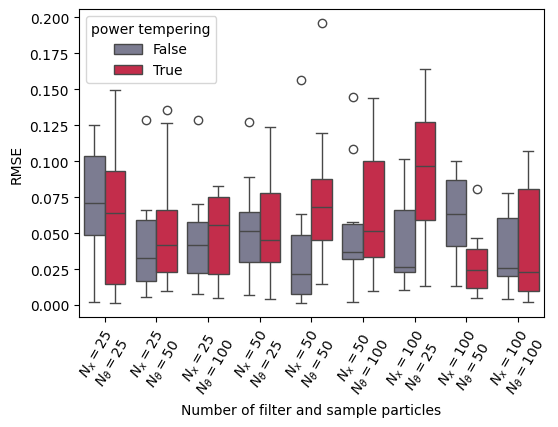

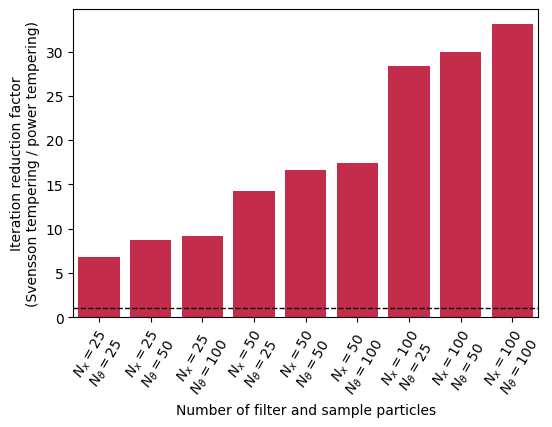

In [96]:
""" Plot RMSE plot
"""

c1 = (120/255, 120/255, 149/255) # Hue colors
c2 = 'crimson'

summary_df["setting"] = (
    r"$N_x=$" + summary_df["n_filter_particles"].astype(str)
    + "\n"
    + r"$N_\theta=$" + summary_df["n_sample_particles"].astype(str)
)

plt.figure(figsize=(6,4))

sns.boxplot(
    data=summary_df,
    x="setting",
    y="rmse",
    hue="alternative_tempering",
    palette=[c1,c2]
)

plt.xticks(rotation=60)
plt.ylabel('RMSE')
plt.xlabel('Number of filter and sample particles')
plt.legend(title="power tempering")
plt.savefig("../plots/vs_power_tempering.png", bbox_inches="tight", dpi=300)
plt.show()

""" Investigate number of iterations taken per
tempering scheme
"""

# Median iterations for each parameter combination and tempering scheme
iter_summary = (
    summary_df
    .groupby([
        "n_filter_particles",
        "n_sample_particles",
        "alternative_tempering"
    ], as_index=False)
    .agg(
        median_iterations=("n_iterations", "median"),
        mean_iterations=("n_iterations", "mean"),
        sd_iterations=("n_iterations", "std")
    )
)

# Wide format: one column for Svensson tempering, one for tempering
iter_wide = iter_summary.pivot(
    index=["n_filter_particles", "n_sample_particles"],
    columns="alternative_tempering",
    values="median_iterations"
).reset_index()

iter_wide = iter_wide.rename(columns={
    False: "median_svensson_tempering",
    True: "median_power_tempering"
})

# Reduction factor: >1 means tempering used fewer iterations
iter_wide["iteration_reduction_factor"] = (
    iter_wide["median_svensson_tempering"] / iter_wide["median_power_tempering"]
)

iter_wide["setting"] = (
    r"$N_x=$" + iter_wide["n_filter_particles"].astype(str)
    + "\n"
    + r"$N_\theta=$" + iter_wide["n_sample_particles"].astype(str)
)

plt.figure(figsize=(6, 4))

sns.barplot(
    data=iter_wide,
    x="setting",
    y="iteration_reduction_factor",
    color=c2
)

plt.axhline(1, color="black", linewidth=1, linestyle="--")
plt.xticks(rotation=60)
plt.ylabel("Iteration reduction factor\n(Svensson tempering / power tempering)")
plt.xlabel("Number of filter and sample particles")

plt.savefig("../plots/iteration_reduction_factor.png", bbox_inches="tight", dpi=300)
plt.show()

In [ ]:
""" Experiment 2: no adaptive metropolis-hastings + different parameter choices
    Not included in report
"""

temp = 10.0 # Initial tempering
T = 200 # Number of observations
                              
theta = 1 # True parameter                              

# Keep track of lots of stuff
record_of_records = {}


for mh_sd, mh_iters, repeat, seed in product(
    [0.03, 0.05, 0.1, 0.2],
    [10, 20, 30],
    list(range(5)), # repeats
    list(range(3)) # seeds
):
    params = {
        "seed": seed,
        "repeat": repeat,
        "mh_sd": mh_sd,
        "mh_iters": mh_iters,
    }

    key = tuple(params.items())

    t0 = time.time()
    print(f"Starting run with params {params}")
    
    rng = np.random.default_rng(seed=seed) # Vary the seed
    us = rng.normal(loc=0, scale=1, size=T) 

    # Sample observations from true state-space model
    _, ys = SimpleBenchmarkSSM_simulate(T=T,theta=theta,us=us,rng=rng)


    samples, records = SimpleBenchmarkSSM_smc(
        ys=ys,
        us=us,
        initial_mh_iters=100,
        initial_mh_sd=0.5,
        mh_iters=mh_iters,
        mh_sd=mh_sd,
        n_sample_particles=25,
        n_filter_particles=100,
        temp=temp,
        min_temp=0.01,
        alpha=0.5,
        verbose=False,
        alternative_tempering=False,
        adaptive_pmh=False,
    )

    t1 = time.time()
    print(f"Run took {t1 - t0}s")

    record_of_records[key] = records

Starting run with params {'seed': 0, 'repeat': 0, 'mh_sd': 0.03, 'mh_iters': 10}
Run took 32.03721809387207s
Starting run with params {'seed': 1, 'repeat': 0, 'mh_sd': 0.03, 'mh_iters': 10}
Run took 34.078179597854614s
Starting run with params {'seed': 2, 'repeat': 0, 'mh_sd': 0.03, 'mh_iters': 10}
Run took 31.788525819778442s
Starting run with params {'seed': 0, 'repeat': 1, 'mh_sd': 0.03, 'mh_iters': 10}
Run took 31.253180027008057s
Starting run with params {'seed': 1, 'repeat': 1, 'mh_sd': 0.03, 'mh_iters': 10}
Run took 32.17515778541565s
Starting run with params {'seed': 2, 'repeat': 1, 'mh_sd': 0.03, 'mh_iters': 10}
Run took 33.87740135192871s
Starting run with params {'seed': 0, 'repeat': 2, 'mh_sd': 0.03, 'mh_iters': 10}
Run took 32.54960322380066s
Starting run with params {'seed': 1, 'repeat': 2, 'mh_sd': 0.03, 'mh_iters': 10}
Run took 33.94567942619324s
Starting run with params {'seed': 2, 'repeat': 2, 'mh_sd': 0.03, 'mh_iters': 10}
Run took 22.294912576675415s
Starting run wi

In [31]:
""" Save record of records """

with open("results/experiment_records_2a.pkl", "wb") as f:
    pickle.dump(record_of_records, f)

In [33]:
""" Process experiment data
"""

with open("results/experiment_records_2a.pkl", "rb") as f:
    record_of_records = pickle.load(f)
    

summary_rows = []

for key, records in record_of_records.items():
    params = dict(key)

    if isinstance(records, list):
        final_record = records[-1]
    elif isinstance(records, dict) and "particles" in records:
        final_record = records
    else:
        final_record = list(records.values())[-1]

    particles = np.asarray(final_record["particles"])
    theta_hat = particles.mean()

    summary_rows.append({
        **params,
        "theta_hat": theta_hat,
        "rmse": abs(theta_hat - theta),
        "particle_sd": particles.std(ddof=1),
        "accept_rate": final_record.get("accept_rate", np.nan),
        "final_temp": final_record.get("temp", np.nan),
        "n_final_particles": len(particles),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("results/experiment_summary_2a.csv", index=False)

In [34]:
summary_df["setting"] = (
    "F=" + summary_df["mh_iters"].astype(str)
    + ", S=" + summary_df["mh_sd"].astype(str)
)

# plt.figure(figsize=(12,6))

# sns.boxplot(
#     data=summary_df,
#     x="setting",
#     y="rmse",
#     hue="alternative_tempering"
# )

# plt.xticks(rotation=45)
# plt.show()

g = sns.catplot(
    data=summary_df,
    kind="box",
    x="mh_iters",
    y="rmse",
    col="mh_sd",
    sharey=True
)

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=summary_df,
    x="final_temp",
    y="rmse",
    hue="accept_rate"
)

plt.xlabel("Final temperature")
plt.ylabel("RMSE")
plt.title("RMSE vs final temperature")
plt.show()

plt.figure(figsize=(10,5))

sns.scatterplot(
    data=summary_df,
    x="seed",
    y="theta_hat",
    hue="final_temp",
    palette="viridis"
)

plt.axhline(1, color="red", linestyle="--", label="True parameter")
plt.legend()
plt.ylabel("Final estimate")
plt.title("Final estimate by dataset seed")
plt.show()

seed_summary = (
    summary_df.groupby("seed")
      .agg(
          mean_theta=("theta_hat", "mean"),
          sd_theta=("theta_hat", "std"),
          mean_rmse=("rmse", "mean"),
          mean_temp=("final_temp", "mean")
      )
)

print(seed_summary)

sns.boxplot(
    data=summary_df,
    x="seed",
    y="theta_hat"
)
plt.axhline(1.0, color="red", linestyle="--")

KeyError: 'mh_iters'

In [ ]:
""" Experiment 3: adaptive metropolis-hastings + specific settings, more seeds
    Not included in report
"""

temp = 10.0 # Initial tempering
T = 200 # Number of observations
                              
theta = 1 # True parameter          
                    
n_sample_particles = 50
n_filter_particles = 25

# Keep track of lots of stuff
record_of_records = {}

for seed, repeat, alternative_tempering in product(
    list(range(10)),
    list(range(10)),
    [True, False]
):
    params = {
        "repeat": repeat,
        "seed": seed,
        "alternative_tempering": alternative_tempering
    }
    
    if alternative_tempering:
        temp = 1.0
    else:
        temp = 10.0
    
    rng = np.random.default_rng(seed=seed) # Want to fix this while keeping the rest random
    us = rng.normal(loc=0, scale=1, size=T) 

    # Sample observations from true state-space model
    _, ys = SimpleBenchmarkSSM_simulate(T=T,theta=theta,us=us,rng=rng)

    key = tuple(params.items())

    t0 = time.time()
    print(f"Starting run with params {params}")

    samples, records = SimpleBenchmarkSSM_smc(
        ys=ys,
        us=us,
        initial_mh_iters=100,
        initial_mh_sd=0.5,
        mh_iters=25,
        mh_sd=0.02,
        n_sample_particles=n_sample_particles,
        n_filter_particles=n_filter_particles,
        temp=temp,
        min_temp=0.01,
        alpha=0.4,
        verbose=False,
        alternative_tempering=alternative_tempering,
        adaptive_pmh=True,
    )

    t1 = time.time()
    print(f"Run took {t1 - t0}s")

    record_of_records[key] = records

Starting run with params {'repeat': 0, 'seed': 0, 'alternative_tempering': True}
Run took 3.08508563041687s
Starting run with params {'repeat': 0, 'seed': 0, 'alternative_tempering': False}
Run took 9.082151889801025s
Starting run with params {'repeat': 1, 'seed': 0, 'alternative_tempering': True}
Run took 2.959970474243164s
Starting run with params {'repeat': 1, 'seed': 0, 'alternative_tempering': False}
Run took 9.456039905548096s
Starting run with params {'repeat': 2, 'seed': 0, 'alternative_tempering': True}
Run took 3.025890350341797s
Starting run with params {'repeat': 2, 'seed': 0, 'alternative_tempering': False}
Run took 9.474481582641602s
Starting run with params {'repeat': 3, 'seed': 0, 'alternative_tempering': True}
Run took 2.989190101623535s
Starting run with params {'repeat': 3, 'seed': 0, 'alternative_tempering': False}
Run took 8.45433497428894s
Starting run with params {'repeat': 4, 'seed': 0, 'alternative_tempering': True}
Run took 2.957277774810791s
Starting run with

In [47]:
""" Save record of records """

with open("results/experiment_records_3e.pkl", "wb") as f:
    pickle.dump(record_of_records, f)

In [52]:
""" Process experiment data
"""

with open("results/experiment_records_3e.pkl", "rb") as f:
    record_of_records = pickle.load(f)
    

summary_rows = []

for key, records in record_of_records.items():
    params = dict(key)

    if isinstance(records, list):
        final_record = records[-1]
    elif isinstance(records, dict) and "particles" in records:
        final_record = records
    else:
        final_record = list(records.values())[-1]

    particles = np.asarray(final_record["particles"])
    theta_hat = particles.mean()

    summary_rows.append({
        **params,
        "theta_hat": theta_hat,
        "rmse": abs(theta_hat - theta),
        "particle_sd": particles.std(ddof=1),
        "accept_rate": final_record.get("accept_rate", np.nan),
        "final_temp": final_record.get("temp", np.nan),
        "n_final_particles": len(particles),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("results/experiment_summary_3e.csv", index=False)

<Axes: xlabel='seed', ylabel='rmse'>

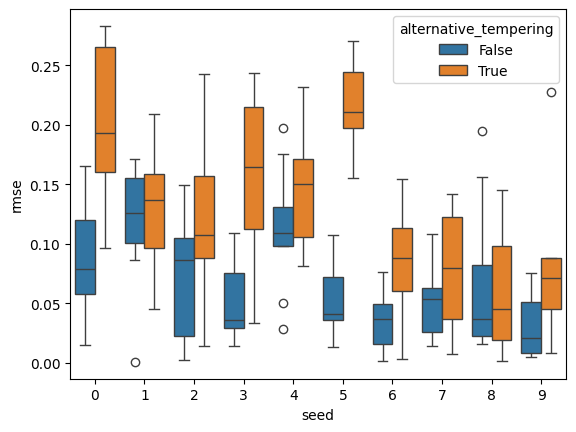

In [54]:


sns.boxplot(
    data=summary_df,
    x="seed",
    y="rmse",
    hue="alternative_tempering"
)


In [111]:
""" Code for log-likelihood estimate variance estimation
"""

""" Piece of code for estimating the variance of
a particle filter likelihood estimate at a given parameter value
"""

@njit(parallel=True)
def estimate_log_marginal_variance_parallel(temp, n_particles, ys, us, thetas, n_repeats, alternative_tempering):
    n_samples = thetas.shape[0]

    # log marginal likelihood estimate for each repeat
    log_marginals = np.empty(n_repeats, dtype=np.float64)

    for r in prange(n_repeats):
        log_liks = np.empty(n_samples, dtype=np.float64)

        for m in range(n_samples):
            _, _, log_lik = SimpleBenchmarkSSM_bootstrap_pf(temp, n_particles, ys, us, thetas[m], alternative_tempering)
            log_liks[m] = log_lik

        max_log_lik = np.max(log_liks)
        log_marginals[r] = max_log_lik + np.log(np.mean(np.exp(log_liks - max_log_lik)))

    return np.mean(log_marginals), np.var(log_marginals), np.std(log_marginals)

In [122]:
""" Save the latest record """

with open("results/experiment_records_1e.pkl", "rb") as f:
    record_of_records = pickle.load(f)


T = 200 # Make sure that this is same as when running experiment
theta = 1

# Make sure that these are the same as used when doing the experiment
rng = np.random.default_rng(seed=42) # Want to fix this while keeping the rest random
us = rng.normal(loc=0, scale=1, size=T) 

# Sample observations from true state-space model
_, ys = SimpleBenchmarkSSM_simulate(T=T,theta=theta,us=us,rng=rng)


log_marginal_summ = {}

# Compute variance of log marginal likelihood estimates over all records
# and store in a nice big dictionary.
for i, (key, records) in enumerate(record_of_records.items()):
    params = dict(key)
        
    alternative_tempering = params['alternative_tempering']
    n_filter_particles = params['n_filter_particles']

    log_marginal_summ_onerec = {}
    
    print(f'Treating record {i} of {len(record_of_records.keys())}')
    
    for _, recs in records.items():
                
        particles = np.asarray(recs["particles"])
        temp = np.float64(np.asarray(recs["temp"]))
        
        mean_log_marginal, var_log_marginal, _ = estimate_log_marginal_variance_parallel(temp=temp,
                                                n_particles=n_filter_particles,
                                                ys=ys,
                                                us=us,
                                                thetas=particles,
                                                n_repeats=10,
                                                alternative_tempering=alternative_tempering)
        log_marginal_summ_onerec[temp] = {'mean': mean_log_marginal, 'var': var_log_marginal}
    
    log_marginal_summ[key] = log_marginal_summ_onerec
    print(f'DEBUG: new entry added {log_marginal_summ_onerec}')

Treating record 0 of 180
DEBUG: new entry added {np.float64(1.0): {'mean': -25297.393640266186, 'var': 16466006.117204916}, np.float64(0.9999999981379732): {'mean': -27877.32831106238, 'var': 8035839.112606322}, np.float64(0.9999973279989041): {'mean': -24029.834007387886, 'var': 3652674.5317860367}, np.float64(0.9999697120494222): {'mean': -19567.709425487286, 'var': 5217611.548986078}, np.float64(0.9998063812463288): {'mean': -20609.575287861087, 'var': 3365043.11729291}, np.float64(0.9995458502393021): {'mean': -20463.77077699162, 'var': 1282385.9793768846}, np.float64(0.999127317310281): {'mean': -19296.179722775745, 'var': 1611037.999698592}, np.float64(0.9985792569204216): {'mean': -19377.247899702594, 'var': 2657882.902736457}}
Treating record 1 of 180
DEBUG: new entry added {np.float64(1.0): {'mean': -26509.128334540255, 'var': 12966875.3758767}, np.float64(0.9999999976589606): {'mean': -23544.510015591517, 'var': 4909594.444074284}, np.float64(0.9999975340499863): {'mean': -22

In [ ]:
# """ Save result from latest cell
# """

# summary_df = pd.DataFrame(log_marginal_summ)
# summary_df.to_csv("results/experiment_summary_4e.csv", index=False)

In [265]:
alt_true = {
    k: v
    for k, v in log_marginal_summ.items()
    if dict(k)["alternative_tempering"] is True
}

alt_false = {
    k: v
    for k, v in log_marginal_summ.items()
    if dict(k)["alternative_tempering"] is False
}


def collect_log_variances(results_dict):
    vals = []

    for run in results_dict.values():
        for stats in run.values():
            vals.append(np.log10(stats["var"]))

    return np.array(vals)


power = collect_log_variances(alt_true)
svensson = collect_log_variances(alt_false)


def summarize(x):
    return {
        "N": len(x),
        "Mean log10(var)": np.mean(x),
        "Median log10(var)": np.median(x),
        "Min log10(var)": np.min(x),
        "Q25": np.percentile(x, 25),
        "Q75": np.percentile(x, 75),
        "Max log10(var)": np.max(x),
        "IQR": np.percentile(x, 75) - np.percentile(x, 25),
        "Min variance": 10 ** np.min(x),
        "Median variance": 10 ** np.median(x),
        "Max variance": 10 ** np.max(x),
    }


summary = pd.DataFrame(
    {
        "Power tempering": summarize(power),
        "Svensson tempering": summarize(svensson),
    }
).T


for col in ["Min variance", "Median variance", "Max variance"]:
    summary[col] = summary[col].map(lambda x: f"{x:.2e}")


numeric_cols = [
    "Mean log10(var)",
    "Median log10(var)",
    "Min log10(var)",
    "Q25",
    "Q75",
    "Max log10(var)",
    "IQR",
]

summary[numeric_cols] = summary[numeric_cols].round(3)

print(summary)

                          N  Mean log10(var)  Median log10(var)  \
Power tempering       646.0            6.047              6.046   
Svensson tempering  11346.0           -0.698             -0.675   

                    Min log10(var)    Q25    Q75  Max log10(var)    IQR  \
Power tempering              4.855  5.754  6.307           7.598  0.554   
Svensson tempering          -2.609 -1.065 -0.321           0.703  0.745   

                   Min variance Median variance Max variance  
Power tempering        7.16e+04        1.11e+06     3.97e+07  
Svensson tempering     2.46e-03        2.11e-01     5.04e+00  


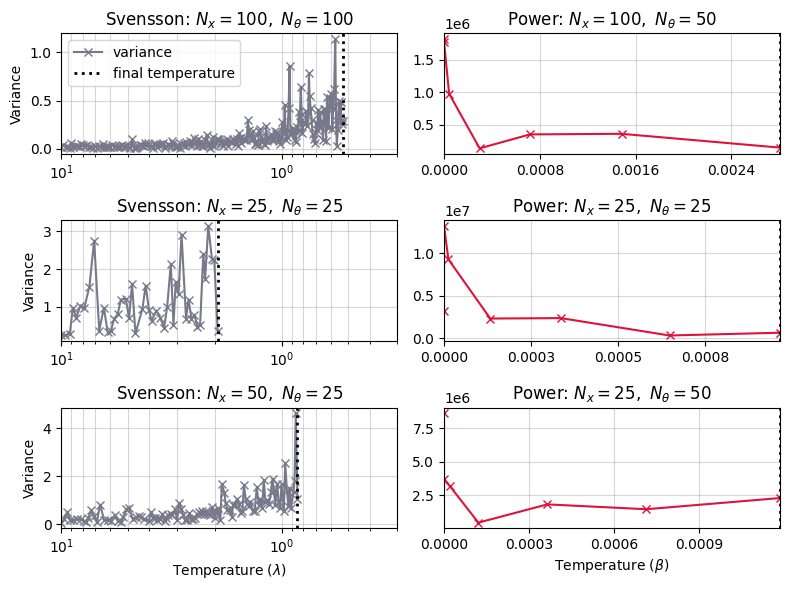

In [264]:
from matplotlib.ticker import FuncFormatter, MaxNLocator

def sample_runs(results, alt_tempering, n=3):
    eligible = [
        (key, run)
        for key, run in results.items()
        if dict(key).get("alternative_tempering") is alt_tempering
    ]

    idx = np.random.choice(len(eligible), size=n, replace=False)
    return [eligible[i] for i in idx]


svensson_runs = sample_runs(log_marginal_summ, alt_tempering=False, n=3)
power_runs = sample_runs(log_marginal_summ, alt_tempering=True, n=3)


fig, axs = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(8, 6),
    sharey=False,
)

for row in range(3):
    for col, runs, title_prefix in [
        (0, svensson_runs, "Svensson"),
        (1, power_runs, "Power"),
    ]:
        ax = axs[row, col]

        key, run = runs[row]
        key_info = dict(key)

        temps_evaluated = np.array(sorted(run.keys(), reverse=True), dtype=float)
        variances = np.array([run[t]["var"] for t in temps_evaluated], dtype=float)

        furthest_temp = np.min(temps_evaluated)
        initial_temp = np.max(temps_evaluated)

        if col == 0:
            ax.plot(
                temps_evaluated,
                variances,
                marker="x",
                color=(120 / 255, 120 / 255, 139 / 255),
                label="variance" if (row == 0 and col == 0) else None,
            )

            ax.axvline(
                furthest_temp,
                color="black",
                linestyle=":",
                linewidth=2,
                label="final temperature" if (row == 0 and col == 0) else None,
            )

            ax.set_xscale("log")
            ax.invert_xaxis()
            ax.set_xlim(initial_temp * 1, 0.3)

        else:
            beta = 1.0 - temps_evaluated
            final_beta = 1.0 - furthest_temp
            
            ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
            ax.xaxis.set_major_formatter(
                FuncFormatter(lambda x, pos: f"{x:.4f}")
            )

            order = np.argsort(beta)
            beta = beta[order]
            variances_plot = variances[order]

            ax.plot(
                beta,
                variances_plot,
                marker="x",
                color="crimson",
            )

            ax.axvline(
                final_beta,
                color="black",
                linestyle=":",
                linewidth=2,
            )

            ax.set_xlim(0.0, final_beta * 1)

        ax.grid(True, which="both", ls="-", alpha=0.5)

        if col == 0:
            ax.set_ylabel("Variance")

        ax.set_title(
            rf"{title_prefix}: "
            rf"$N_x={key_info['n_filter_particles']},\ "
            rf"N_\theta={key_info['n_sample_particles']}$"
        )


axs[-1, 0].set_xlabel(r"Temperature ($\lambda$)")
axs[-1, 1].set_xlabel(r"Temperature ($\beta$)")

axs[0, 0].legend(loc="upper left")

plt.tight_layout()
plt.savefig("../plots/variance_power_svensson.png", bbox_inches="tight", dpi=300)
plt.show()

In [ ]:
""" A final experiment running power tempering on the larger
non-linear model
"""

temp = 1.0 # Initial tempering
T = 200 # Number of observations
                              
# Exogenous input variables
rng = np.random.default_rng(seed=42) # Want to fix this while keeping the rest random
us = rng.normal(loc=0, scale=1, size=T)

theta = np.asarray([1,1])

# Sample observations from true state-space model
ys = Svensson2017NonLinearSSM_simulate(T=T,u=us,theta=theta,rng=rng)


record_of_records = {}

for n_filter_particles, n_sample_particles, repeat in product(
    [50, 150, 300],
    [50, 150, 300],
    list(range(10))
):
        
    params = {
        "repeat": repeat,
        "n_filter_particles": n_filter_particles,
        "n_sample_particles": n_sample_particles,
    }

    key = tuple(params.items())

    t0 = time.time()
    print(f"Starting run with params {params}")

    samples, records = Svensson2017NonLinearSSM_smc(
        ys=ys,
        us=us,
        initial_mh_iters=100,
        initial_mh_sd=0.5,
        mh_iters=25,
        mh_sd=0.02,
        n_sample_particles=n_sample_particles,
        n_filter_particles=n_filter_particles,
        temp=temp,
        min_temp=0.01,
        alpha=0.5,
        verbose=False,
        alternative_tempering=True,
        adaptive_pmh=True,
    )

    t1 = time.time()
    print(f"Run took {t1 - t0}s")

    record_of_records[key] = records

TypeError: Svensson2017NonLinearSSM_simulate() missing 1 required positional argument: 'theta'